# Watershed Room Segmentation  - Geometric + SAM method (stage 1 of 3)

**Method: geometric + SAM.** This is the *same* deterministic watershed as
`methods/geometric/notebook_1_watershed.ipynb`, run as the **first stage of the
geometric+SAM pipeline**. The only difference is the output location: it writes to a
**distinct** stage directory (`stage_geometric_sam_watershed/`) so the pure-geometric and
the geometric+SAM methods never clobber each other's room masks.

> **Three-method comparison.** The project compares room segmentation by three methods  -
> **geometric** (watershed only), **SAM** (SAM auto-segmentation), and **geometric+SAM**
> (watershed prior, then prompted-SAM refinement). This notebook is stage 1 of the
> geometric+SAM method; `notebook_2_sam_refinement.ipynb` then refines these masks and
> `notebook_3_wall_assignment.ipynb` assigns walls on the refined masks.

## Purpose
Produce the geometric room-segmentation masks with the original deterministic
distance-transform watershed. **No algorithmic change**  - the logic lives in
`scan2bim.segment_rooms_watershed` and is called here unchanged.

## Inputs  (from `stage1_occupancy.zip`)
- `wall_mask.npy` (or `wallness.npy` when `CFG.use_wallness=True`)  - segmentation input.
- `coverage.npy`  - for void rejection.
- `transform.json`  - carried forward for downstream alignment.

## Outputs  (`{out_root}/stage_geometric_sam_watershed/`, zipped)
- `room_labels.npy`  - int32 labels: `-1` wall / `0` exterior / `>=1` rooms.
- `room_labels_color.png`  - colourised labels for QA.
- `walls.npy`  - the cleaned wall mask the watershed used.
- `footprint.npy`  - building footprint (needed by the SAM refinement stage).
- `transform.json`, `config.json`.

## Assumptions
- Rasters were produced by the preprocessing occupancy notebook with the same `CFG`.

### Setup
**Run-All ready.** Edit **`params.yaml`** (the only config surface), then run every cell top
to bottom  - no cell edits, ever. `load_config()` reads it over the `Config` defaults.

> **Skipped `pip install -e .`?** Prepend this 2-line path-shim to the cell below so
> `import scan2bim` resolves from `notebooks/methods/geometric_SAM/`:
> `import sys, os; sys.path.insert(0, os.path.abspath('../../..'))`

In [1]:
import sys, os
import numpy as np

PROJECT_ROOT = os.path.abspath('../../..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
sys.path = [p for p in sys.path if not p.endswith('/src') and not p.endswith('\\src')]
for mod in list(sys.modules):
    if mod == 'scan2bim' or mod.startswith('scan2bim.'):
        del sys.modules[mod]

import scan2bim
from scan2bim import artifacts as A, viz

CFG = scan2bim.load_config()
SHOW_DEBUG = True
print('scan2bim', scan2bim.__version__, 'loaded from', os.path.dirname(scan2bim.__file__))
print('input cloud :', CFG.file_path, '| exists:', os.path.isfile(CFG.file_path))
print('output root :', CFG.out_root)

scan2bim 1.0.0 loaded from /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/scan2bim
input cloud : /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/data/area1.xyz | exists: True
output root : /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/scan2bim_out


### Step 1  - Load the Stage-1 rasters

In [2]:
s1 = A.load_stage_dir(CFG.out_root, A.STAGE1)
scan2bim.assert_upstream_config(CFG, A.load_stage_config(s1))   # same cloud + grid as stage 1
wall_mask = A.load_npy(os.path.join(s1, A.WALLMASK_NPY)).astype(bool)
wallness  = A.load_npy(os.path.join(s1, A.WALLNESS_NPY)).astype(bool)
coverage  = A.load_npy(os.path.join(s1, A.COVERAGE_NPY)).astype(bool)
tf = A.load_transform(os.path.join(s1, A.TRANSFORM_JSON))

# Preserve the original segmentation-input choice (binary occupancy by default).
seg_input = wallness if CFG.use_wallness else wall_mask
print('segmentation input:', 'wallness' if CFG.use_wallness else 'wall_mask',
      '| shape', seg_input.shape)

segmentation input: wall_mask | shape (1606, 1618)


### Step 2  - Run the watershed (unchanged algorithm)

In [3]:
labels, aux = scan2bim.segment_rooms_watershed(
    seg_input, CFG.pixel_m,
    marker_h_m=CFG.marker_h_m, footprint_close_m=CFG.footprint_close_m,
    merge_ridge_m=CFG.merge_ridge_m, min_room_area_m2=CFG.min_room_area_m2,
    min_wall_area_px=CFG.min_wall_area_px, door_seal_px=CFG.seal_gap_px,
    coverage=coverage, min_coverage_frac=CFG.min_coverage_frac, return_aux=True)
n_rooms = len([r for r in np.unique(labels) if r >= 1])
print('rooms found:', n_rooms)

rooms found: 53


### Optional  - QA plots

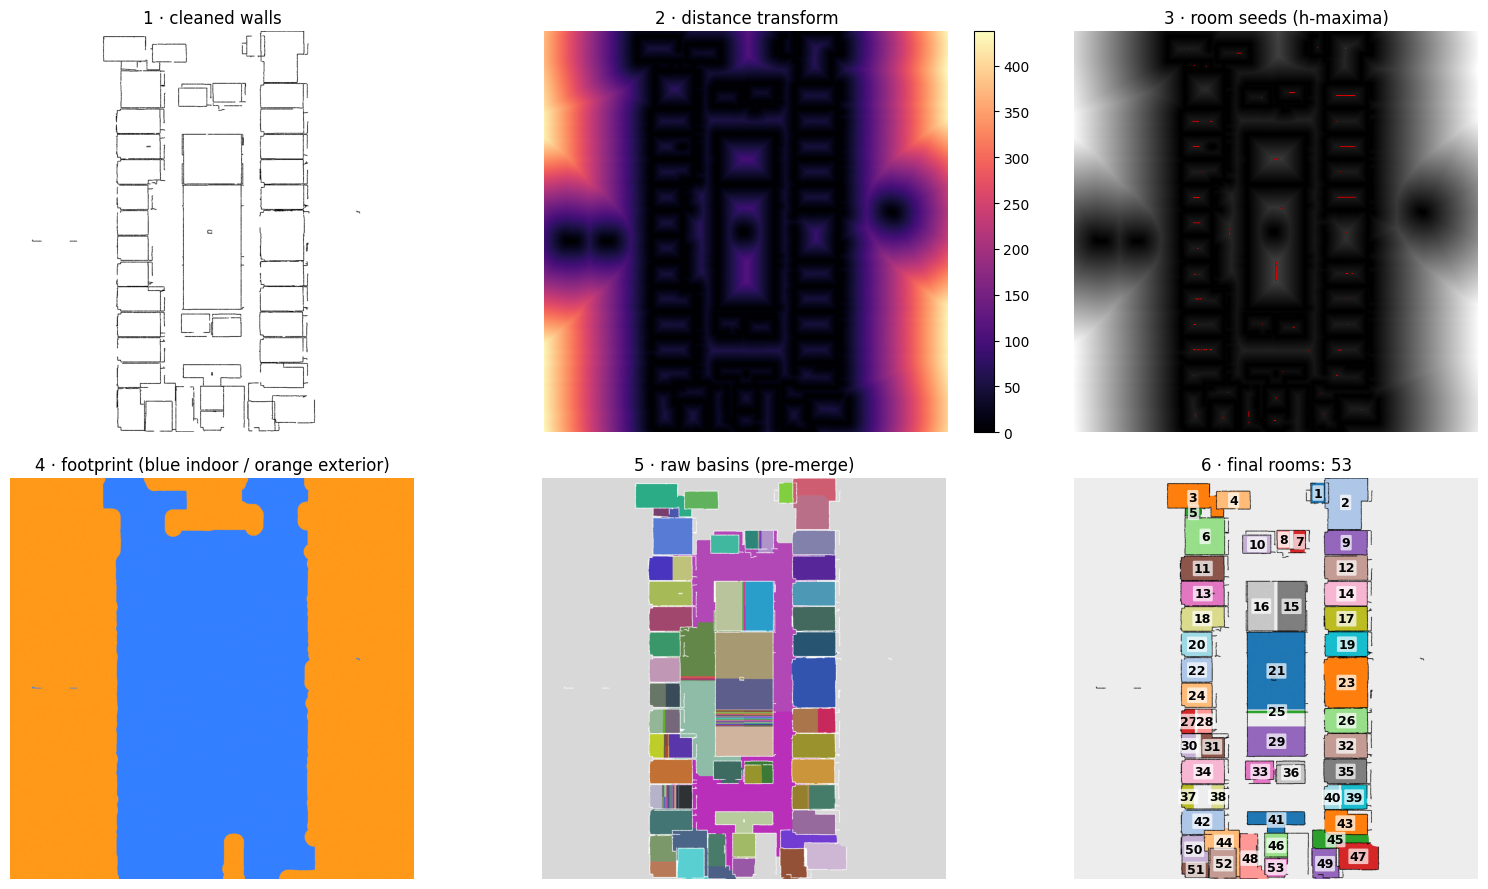

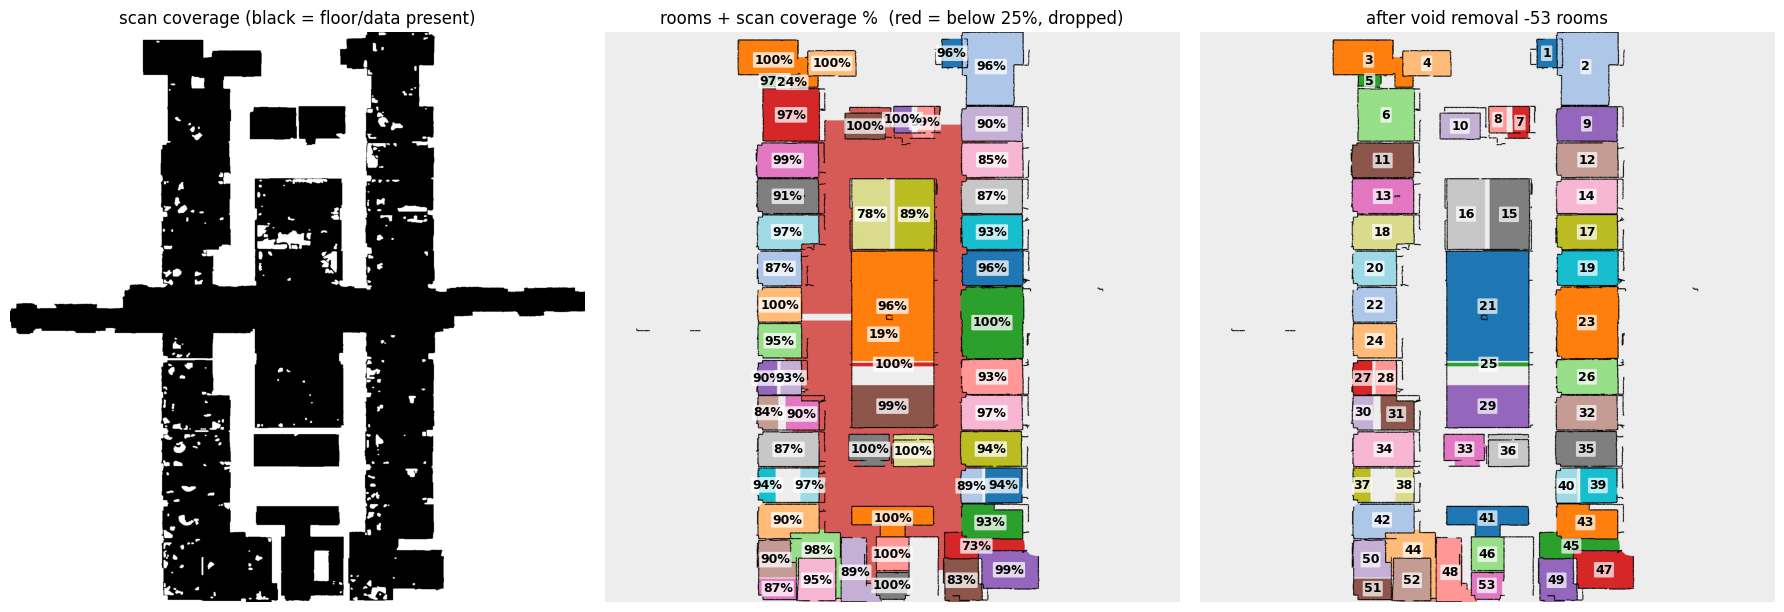

In [4]:
if SHOW_DEBUG:
    viz.show_watershed_internals(aux, labels, CFG.pixel_m)
    if aux.get('coverage') is not None:
        viz.show_coverage_debug(aux, labels, CFG)

### Step 3  - Save outputs and package the ZIP

In [5]:
# Geometric+SAM method writes its watershed to a DISTINCT stage dir so it never clobbers the
# pure-geometric run's `stage2_watershed/`. Everything else is identical to
# methods/geometric/notebook_1_watershed.ipynb.
STAGE = 'stage2_watershed'
out_dir = A.ensure_dir(A.stage_dir(CFG.out_root, STAGE))
A.save_npy(os.path.join(out_dir, A.ROOM_LABELS_NPY), labels.astype('int32'))
A.save_label_png(os.path.join(out_dir, A.ROOM_LABELS_PNG), labels)
A.save_npy(os.path.join(out_dir, A.WATERSHED_WALLS_NPY), aux['walls'].astype(bool))
A.save_npy(os.path.join(out_dir, A.FOOTPRINT_NPY), aux['footprint'].astype(bool))
# carry the transform forward unchanged
A.save_transform(os.path.join(out_dir, A.TRANSFORM_JSON), tf)
A.save_config(os.path.join(out_dir, A.CONFIG_JSON), CFG)
zip_path = A.package_stage(CFG.out_root, STAGE)
print('packaged ->', zip_path)

packaged -> /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/scan2bim_out/stage2_watershed.zip
